<a href="https://colab.research.google.com/github/ankurs190/Agentic-2.0/blob/main/19_%26_20_July_Day_21%2622_Autogen_Studio_%26_Project_Advanced.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#### **19 July Day - 21 Autogen Studio**

In [ ]:
# !pip install -qU  python-dotenv autogen_agentchat autogen_ext langchain_community
#API_KEYS

##### **Graph Flow in Autogen**

https://microsoft.github.io/autogen/stable/user-guide/agentchat-user-guide/graph-flow.html

In [ ]:
import asyncio
from autogen_agentchat.agents import AssistantAgent,UserProxyAgent
from autogen_agentchat.teams import SelectorGroupChat
from autogen_ext.models.openai import OpenAIChatCompletionClient
from autogen_agentchat.conditions import TextMentionTermination

# Create an OpenAI model client
model_client = OpenAIChatCompletionClient(model='gpt-4o', api_key=OPENAI_API_KEY)

In [ ]:
from autogen_agentchat.teams import DiGraphBuilder, GraphFlow

In [ ]:
# Sequential Flow

# Create the writer agent
writer = AssistantAgent(
    name="Writer",
    description="A writer agent that generates text based on user input.",
    model_client=model_client,
    system_message="You are a creative writer. Please write a story based on the user's input.",
)

# # Create the reviwer agent
reviewer = AssistantAgent(
    name="Reviewer",
    description="A reviewer agent that provides feedback on the text generated by the writer.",
    model_client=model_client,
    system_message="You are a reviewer. Please provide feedback on the text generated by the writer.",
)

# Build the graph
builder = DiGraphBuilder()
builder.add_node(writer).add_node(reviewer)
builder.add_edge(writer, reviewer)

# Build and validate the graph
graph = builder.build()
graph

DiGraph(nodes={'Writer': DiGraphNode(name='Writer', edges=[DiGraphEdge(target='Reviewer', condition=None, condition_function=None, activation_group='Reviewer', activation_condition='all')], activation='all'), 'Reviewer': DiGraphNode(name='Reviewer', edges=[], activation='all')}, default_start_node=None)

In [ ]:
# Create the flow
team = GraphFlow(participants=[writer,reviewer], graph= graph)
stream = team.run_stream(task ="Write a good poem about India in less than 30 words.")

async for event in stream:
    print(event)

id='d5e59d81-1bf1-4297-baea-6a582653f8f1' source='user' models_usage=None metadata={} created_at=datetime.datetime(2025, 8, 4, 11, 33, 26, 760618, tzinfo=datetime.timezone.utc) content='Write a good poem about India in less than 30 words.' type='TextMessage'
id='4c8b2fb6-7f39-47dd-96f5-a75141b25f66' source='Writer' models_usage=RequestUsage(prompt_tokens=41, completion_tokens=32) metadata={} created_at=datetime.datetime(2025, 8, 4, 11, 33, 28, 781163, tzinfo=datetime.timezone.utc) content="Vast lands where spices dance,  \nRivers hum a timeless trance.  \nUnity in colors, cultures blend,  \nIndia's heart, an endless friend." type='TextMessage'
id='267065bd-f8bf-4853-8e95-25c6c91bfdf4' source='Reviewer' models_usage=RequestUsage(prompt_tokens=79, completion_tokens=109) metadata={} created_at=datetime.datetime(2025, 8, 4, 11, 33, 32, 139247, tzinfo=datetime.timezone.utc) content='This poem beautifully captures the essence of India in just a few lines. The use of vivid imagery, like "spic

In [ ]:
# parallel flow
import asyncio

from autogen_agentchat.agents import AssistantAgent
from autogen_agentchat.conditions import MaxMessageTermination
from autogen_agentchat.teams import DiGraphBuilder, GraphFlow
from autogen_ext.models.openai import OpenAIChatCompletionClient


async def main():
    # Initialize agents with OpenAI model clients.
    model_client = OpenAIChatCompletionClient(model="gpt-4.1-nano", api_key=OPENAI_API_KEY)
    agent_a = AssistantAgent("A", model_client=model_client, system_message="You are a helpful assistant.")
    agent_b = AssistantAgent("B", model_client=model_client, system_message="Translate input to Chinese.")
    agent_c = AssistantAgent("C", model_client=model_client, system_message="Translate input to Japanese.")

    # Create a directed graph with fan-out flow A -> (B, C).
    builder = DiGraphBuilder()
    builder.add_node(agent_a).add_node(agent_b).add_node(agent_c)

    # parallel flow
    builder.add_edge(agent_a, agent_b).add_edge(agent_a, agent_c)

    # sequential flow

    # builder.add_edge(agent_a, agent_b)
    # builder.add_edge(agent_b,agent_c)
    graph = builder.build()

    # Create a GraphFlow team with the directed graph.
    team = GraphFlow(
        participants=[agent_a, agent_b, agent_c],
        graph=graph,
        termination_condition=MaxMessageTermination(5),
    )

    # Run the team and print the events.
    async for event in team.run_stream(task="Write a short story about a cat."):
        print(event)


await main()   # B & C running parallel

# use case: Research papaers : combine result from multiple resources

id='272de3e7-94ed-4719-826f-1f3d7bee3535' source='user' models_usage=None metadata={} created_at=datetime.datetime(2025, 8, 4, 11, 33, 32, 261170, tzinfo=datetime.timezone.utc) content='Write a short story about a cat.' type='TextMessage'
id='4276f110-cec5-4468-84d1-768eb0ca3abe' source='A' models_usage=RequestUsage(prompt_tokens=26, completion_tokens=238) metadata={} created_at=datetime.datetime(2025, 8, 4, 11, 33, 36, 132527, tzinfo=datetime.timezone.utc) content="Once upon a time, in a cozy little village, there was a curious cat named Oliver. His fur was as soft as clouds, and his bright green eyes sparkled with wonder. Oliver loved to explore every nook and cranny of the village, from the bustling marketplace to the quiet gardens.\n\nOne sunny morning, Oliver spotted a shimmering object near the fountain in the town square. With a leap and a pounce, he discovered it was a tiny, glittering key. Intrigued, Oliver decided to find out what it unlocked. He searched high and low, asking

In [ ]:
import asyncio
from autogen_agentchat.agents import AssistantAgent
from autogen_agentchat.conditions import MaxMessageTermination
from autogen_agentchat.teams import DiGraphBuilder, GraphFlow
from autogen_ext.models.openai import OpenAIChatCompletionClient


async def main():
    # Initialize agents with OpenAI model clients.
    model_client = OpenAIChatCompletionClient(model="gpt-4.1-nano", api_key=OPENAI_API_KEY)
    agent_a = AssistantAgent("A", model_client=model_client, system_message="Detect if the input is in Chinese. If it is, say 'yes', else say 'no', and nothing else.")
    agent_b = AssistantAgent("B", model_client=model_client, system_message="Translate input to English.")
    agent_c = AssistantAgent("C", model_client=model_client, system_message="Translate input to Chinese.")

    # Create a directed graph with conditional branching flow A -> B ("yes"), A -> C (otherwise).
    builder = DiGraphBuilder()
    builder.add_node(agent_a).add_node(agent_b).add_node(agent_c)
    # Create conditions as callables that check the message content.
    builder.add_edge(agent_a, agent_b, condition=lambda msg: "yes" in msg.to_model_text())
    builder.add_edge(agent_a, agent_c, condition=lambda msg: "yes" not in msg.to_model_text())
    graph = builder.build()

    # Create a GraphFlow team with the directed graph.
    team = GraphFlow(
        participants=[agent_a, agent_b, agent_c],
        graph=graph,
        termination_condition=MaxMessageTermination(5),
    )

    # Run the team and print the events.
    async for event in team.run_stream(task="AutoGen is a framework for building AI agents."):
        print(event)

await main()

id='614468e5-6354-4fe4-be97-880778a14749' source='user' models_usage=None metadata={} created_at=datetime.datetime(2025, 8, 4, 11, 33, 40, 855380, tzinfo=datetime.timezone.utc) content='AutoGen is a framework for building AI agents.' type='TextMessage'
id='0c7cb81d-7a22-4ab7-9820-74479d4e4b3b' source='A' models_usage=RequestUsage(prompt_tokens=47, completion_tokens=1) metadata={} created_at=datetime.datetime(2025, 8, 4, 11, 33, 41, 298614, tzinfo=datetime.timezone.utc) content='no' type='TextMessage'
id='91acadd7-247b-4d04-bf64-98ccde26a9a0' source='C' models_usage=RequestUsage(prompt_tokens=33, completion_tokens=14) metadata={} created_at=datetime.datetime(2025, 8, 4, 11, 33, 41, 643058, tzinfo=datetime.timezone.utc) content='AutoGen是一个用于构建人工智能代理的框架。' type='TextMessage'
messages=[TextMessage(id='614468e5-6354-4fe4-be97-880778a14749', source='user', models_usage=None, metadata={}, created_at=datetime.datetime(2025, 8, 4, 11, 33, 40, 855380, tzinfo=datetime.timezone.utc), content='AutoG

https://www.youtube.com/watch?v=DkV7ztrhLh8 - n8n Mayank Agarwal

##### **MCP**

  - Why MCP was developed, specifically in the context of tools, and how it helps non-coders or agents avoid writing boilerplate code.

    🛠️ Problem Before MCP: Tool Use Was Messy
      - Imagine you're building an AI agent that needs to:
        - Call a calculator
        - Fetch data from a weather API
        - Run a Python code block
      
      - Without MCP:
        - You had to manually define how the tool is called (e.g., construct the function call).
        - You had to parse the model's response to see if it wanted to call the tool.
        - You had to wrap tool outputs into the model context correctly.

        💻 That means: everyone had to write their own tool integration logic—even just to call a calculator!

      - ✅ MCP Solves This: Tools Work Out of the Box
        - With MCP: Tools are automatically wrapped into a standard format.
        - The model can say: 👉 "I want to call run_code with {'code': '2+2'}"

      - MCP handles:
          - Formatting the request
          - Executing the tool
          - Inserting the result back into the chat as a message
          - The agent simply continues the conversation with the tool result already inserted.

🔍 Example: Code Execution Tool
  - You don’t need to write:
          if "run_code" in response:
              parse arguments
              execute the code
              feed it back
  - Instead, just define:
        from autogen import CodeExecutorAgent
        agent = CodeExecutorAgent(name="coder")

  - Done. The agent can now:
    -  Understand when code needs to be executed
    - Automatically format a tool call
    - Receive and process tool results
    - No manual code needed. That’s MCP in action.

    📁 Google Drive + MCP in AutoGen: What Does It Mean?
    🔹 Use Case:
    Let’s say you want an agent to:
      - Read a file from Google Drive
      - Write a file to Drive
      - Collaborate on Docs or Sheets
    Normally, you’d have to:
      - Write authentication logic
      - Parse API calls
      - Handle file paths, formats, errors
    😵 That’s a lot of manual plumbing!

    ✅ With MCP: No Manual Code Needed:Thanks to MCP, you can create a Google Drive Tool once, and then:
      - Any agent can ask to "read file abc.txt from Google Drive"
      - The tool knows how to do it
      - The result (file content) comes back in the same message structure MCP uses
      - No special parsing or glue code needed for each agent. ✅

##### **Autogen Studio**

In [ ]:
# https://pypi.org/project/autogenstudio/0.4.2.1/

In [ ]:
# create a new environment becuase (search on chatgpt) - python -m venv ags
# pip install -qU autogenstudio==0.4.2.1  # installing specific version since newer version has lot of issues

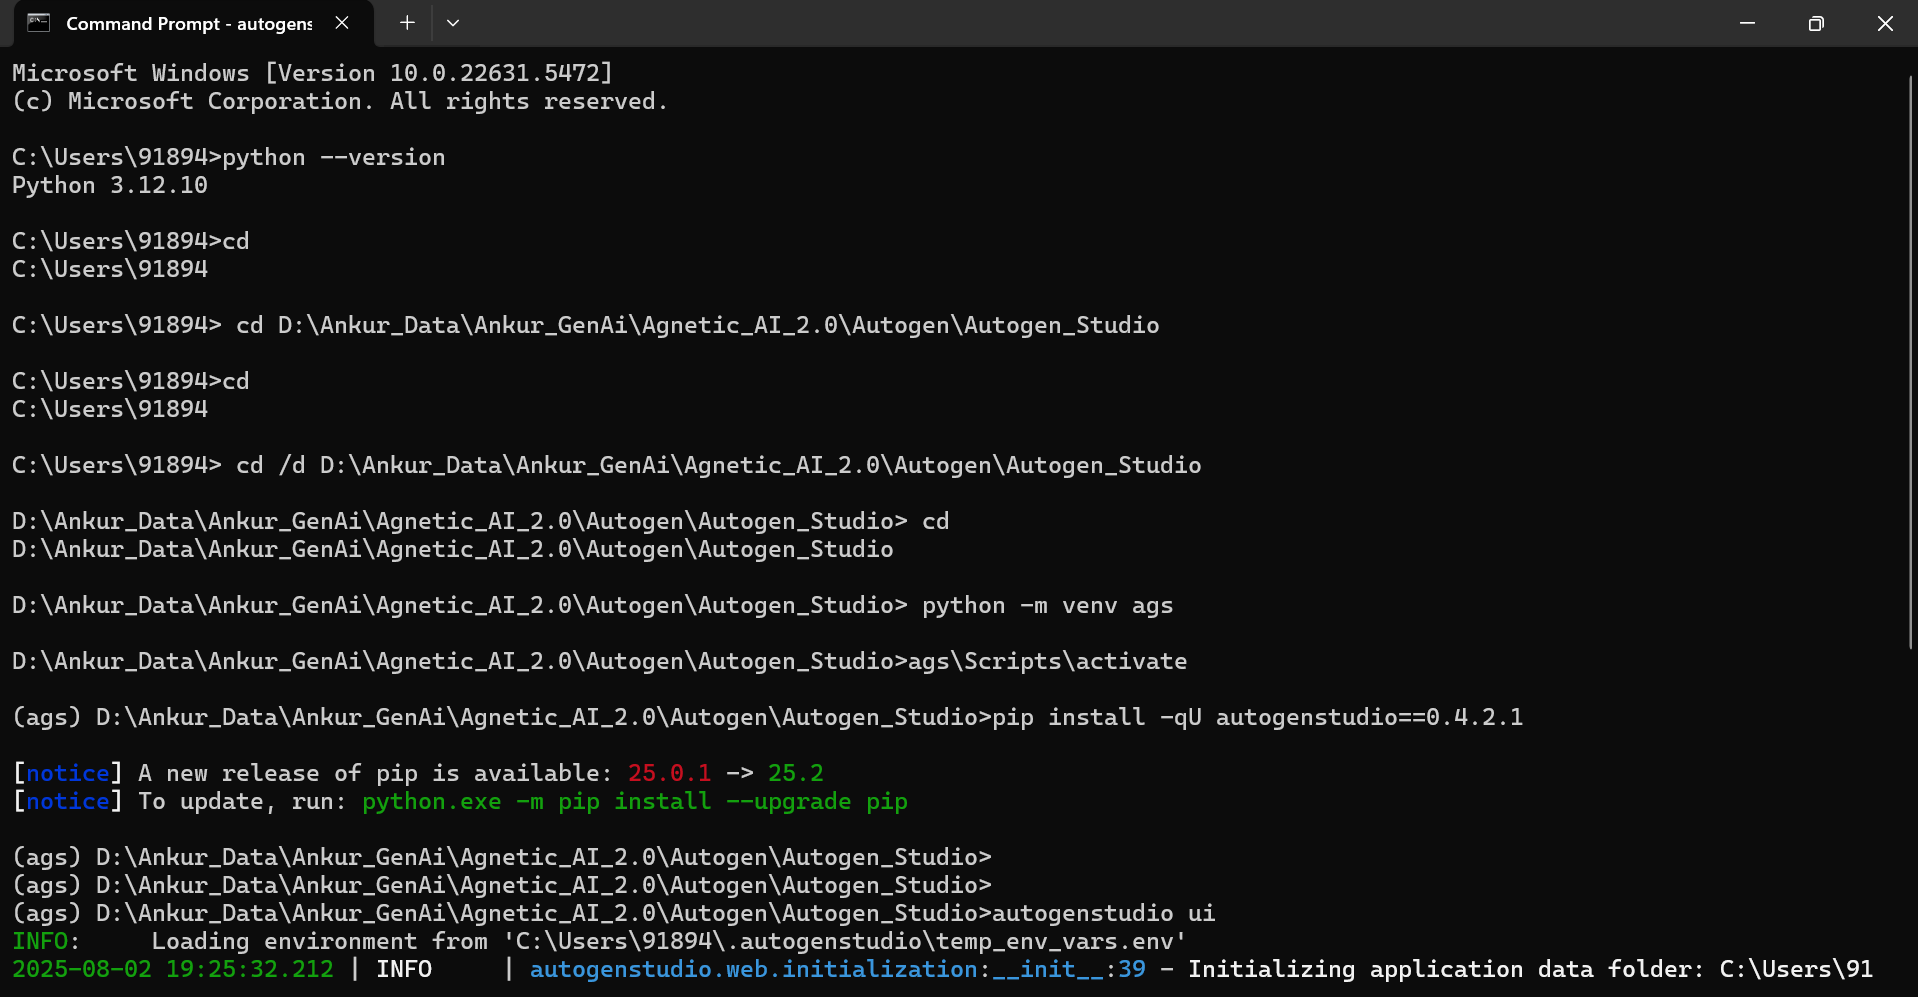


In [ ]:
  # OLLAMA & LM Studio -> UI based tool

#### **20 July Day - 22 Autogen - Project advanced**

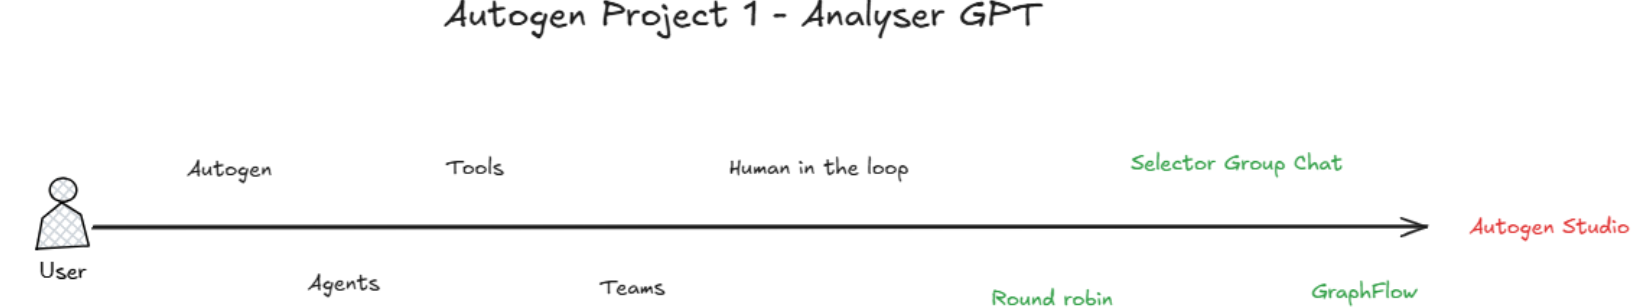

In [ ]:
# https://microsoft.github.io/autogen/stable/user-guide/agentchat-user-guide/examples/literature-review.html


# Digital Data Analyzer
# Give document/ file to analyser GPT ->  ask questions like chatgpt

In [ ]:
# !pip install docker
# !pip install "autogen-ext[docker]"

In [ ]:
from autogen_agentchat.agents import CodeExecutorAgent # just like AssistantAgent, UserProxyAgent. A special agent that executes code blocks sent in messages
import asyncio
from autogen_ext.code_executors.local import LocalCommandLineCodeExecutor # from autogen_ext.code_executors.docker import DockerCommandLineCodeExecutor
from autogen_agentchat.messages import TextMessage  # Message format expected by agents, includes content and source.
from autogen_core import CancellationToken # Allows cancelling the execution mid-way (not used actively here).

async def main():

    docker = LocalCommandLineCodeExecutor(work_dir='tmp',timeout=120)

    code_executor_agent = CodeExecutorAgent(name = 'CodeExecutorAgent', code_executor=docker)

    task = TextMessage(content='''Here is the code
                        ```python
                        print("hello world")
                        ```

                        ```python
                        print("hello world 2")
                        ```
                           ''',
    source='user'
    )

    await docker.start()

    result = await code_executor_agent.on_messages(
        messages=[task],
        cancellation_token=CancellationToken()
    )

    print("The result is",result)

    await docker.stop()


await main()

The result is Response(chat_message=TextMessage(id='8ad227fa-879d-4701-875c-789937971640', source='CodeExecutorAgent', models_usage=None, metadata={}, created_at=datetime.datetime(2025, 8, 4, 11, 33, 41, 745877, tzinfo=datetime.timezone.utc), content='The script ran, then exited with an error (POSIX exit code: 1)\nIts output was:\n  File "/content/tmp/tmp_code_ac55094db11373d3dd484d08bb5d5bde205b80fe0f91f22285d1263caa7cad7b.py", line 1\n    print("hello world")\nIndentationError: unexpected indent\n', type='TextMessage'), inner_messages=None)


###### **Analyzer GPT Project**

In [ ]:
# Code_Executor_ Agent
%%writefile Code_executor_agent.py

from autogen_agentchat.agents import CodeExecutorAgent
def getCodeExecutorAgent(code_executor):

    code_executor_agent = CodeExecutorAgent(
        name='Python_Code_Executor',
        code_executor=code_executor
    )

    return code_executor_agent

Writing Code_executor_agent.py


In [ ]:
%%writefile DATA_ANALYZER_MESSAGE.py
DATA_ANALYZER_SYSTEM_MESSAGE='''
You are a Data analyst agent with expertise in Data analyst and python and working with csv data.
You will be getting a file (data) and will be in the working dir and a question related to this data from the user.

Your job is to write a python code to answer that question.

Here are the steps you should follow :-

1. Start with a plan: Briefly explain how will you solve the problem.
2. Write Python Code : In a single code block make sure to solve the problem.
You have a code executor agent which will be running that code and will tell you if any errors will be there or show the output.
Make sure that your code has a print statement in the end if the task is completed.
Code should be like below, in a single block and no multiple block.
```python
your-code-here
```

3. After writing your code, pause and wait for code executor to run it before continuing.

4. If any library is not installed in the env, please make sure to do the same by providing the bash script and use pip to install(like pip install matplotlib pandas) and after that send the code again without changes , install the required libraries.
example
```bash
pip install pandas numpy matplotlib
```

5. If you are asked to create an image, please make sure that you create the image as output.png and save it in working directory.

6. If the code ran successfully, then analyze the output and continue as needed.


Once we have completed all the task, please mention 'STOP' after explaning in depth the final answer.


Stick to these and ensure a smooth collaboration with Code_executor_agent.
'''

Writing DATA_ANALYZER_MESSAGE.py


In [ ]:
%%writefile Data_analyzer_agent.py

from DATA_ANALYZER_MESSAGE import DATA_ANALYZER_SYSTEM_MESSAGE

# Data_analyzer_agent
from autogen_agentchat.agents import AssistantAgent
def getDataAnalyzerAgent(model_client):
    data_analyzer_agent =
    AssistantAgent(
        name='Data_Analyzer_agent',
        model_client=model_client,
        description = 'An Agent that solves Data Analysis problem and gives the code as well',
        system_message=DATA_ANALYZER_SYSTEM_MESSAGE
    )
    return data_analyzer_agent

Writing Data_analyzer_agent.py


In [ ]:
# model client
%%writefile openai_model_client.py

from autogen_ext.models.openai import OpenAIChatCompletionClient
def get_model_client(api_key):
    openai_model_client = OpenAIChatCompletionClient(
        model='gpt-4o',
        api_key=api_key
    )
    return openai_model_client

Writing openai_model_client.py


In [ ]:
%%writefile docker_util.py
from autogen_ext.code_executors.local import LocalCommandLineCodeExecutor

# from config.constants import WORK_DIR_DOCKER,TIMEOUT_DOCKER

def getDockerCommandLineExecutor():
    docker=LocalCommandLineCodeExecutor(
        image='amancevice/pandas',
        work_dir='tmp',
        timeout=120
    )

    return docker

async def start_docker_container(docker):
    print("Starting Docker Container")
    await docker.start()
    print("Docker Container Started")

async def stop_docker_container(docker):
    print("Stopping Docker Container")
    await docker.stop()
    print("Docker Container Stopped")

Writing docker_util.py


In [ ]:
%%writefile analyzer_gpt.py

# building team

from autogen_agentchat.teams import RoundRobinGroupChat
from autogen_agentchat.conditions import TextMentionTermination

from Code_executor_agent import getCodeExecutorAgent
from Data_analyzer_agent import getDataAnalyzerAgent
from openai_model_client import get_model_client

def getDataAnalyzerTeam(docker,model_client):
    code_executor_agent = getCodeExecutorAgent(docker)  # it requires docker

    data_analyzer_agent = getDataAnalyzerAgent(get_model_client) # it rqeuires model_client

    text_mention_termination = TextMentionTermination('STOP')

    team = RoundRobinGroupChat(
        participants=[data_analyzer_agent,code_executor_agent],
        max_turns=10,
        termination_condition=text_mention_termination
    )
    return team

Writing analyzer_gpt.py


In [ ]:
import asyncio
from teams.analyzer_gpt import getDataAnalyzerTeam
from models.openai_model_client import get_model_client
from config.docker_util import getDockerCommandLineExecutor,start_docker_container,stop_docker_container
from autogen_agentchat.messages import TextMessage


async def main():

    openai_model_client = get_model_client()
    docker = getDockerCommandLineExecutor()

    team = getDataAnalyzerTeam(docker,openai_model_client)

    try:
        task = 'Can you give me a graph of types of flowers in my data iris.csv'

        await start_docker_container(docker)

        async for message in team.run_stream(task=task):
            print(message)

    except Exception as e:
        print(e)
    finally:
        await stop_docker_container(docker)


if(__name__=='__main__'):
    asyncio.run(main())

    Let’s break your Streamlit app down line by line. This app is called “Analyser GPT - Digital Data Analyzer”, and it's designed to:
      - Upload a CSV file
      - Take a user query
      - Pass it to an AutoGen team with an OpenAI model
      - Use a Docker-based or local code executor
      - Show responses in a chat format
      - Display any images generated by the agent (like output.png)



In [ ]:
import streamlit as st # UI framework
import asyncio  # For async execution (needed for async for)
import os  # To handle file system operations

from teams.analyzer_gpt import getDataAnalyzerTeam
from models.openai_model_client import get_model_client
from config.docker_util import getDockerCommandLineExecutor,start_docker_container,stop_docker_container
from autogen_agentchat.messages import TextMessage
from autogen_agentchat.base import TaskResult


st.title('Analyser GPT- Digital Data Analyzer')  #Adds a title
uploaded_file = st.file_uploader("Upload a CSV file", type=["csv"])  # Adds a CSV file uploader widget


# creating streamlit's variable: Streamlit re-runs the script on every interaction — st.session_state stores values across these reruns.

if 'messages' not in st.session_state: #messages: saves the chat history
    st.session_state.messages = []
if 'autogen_team_state' not in st.session_state:  # autogen_team_state: stores internal state of the team (for resuming)
    st.session_state.autogen_team_state = None
if('images_shown') not in st.session_state:  # images_shown: tracks which images have already been displayed
    st.session_state.images_shown=[]

task = st.chat_input("Enter your task here...")  #Adds a chat-style input box. stores user input in task


async def run_analyser_gpt(docker,openai_model_client,task):
    try:
        await start_docker_container(docker)  # Starts the code execution environment (Docker or local)
        team = getDataAnalyzerTeam(docker,openai_model_client) #Creates the agent team with: Docker code executor, OpenAI model client

        if st.session_state.autogen_team_state is not None:  # Allows team to resume previous conversation if already started
            await team.load_state(st.session_state.autogen_team_state)

        async for message in team.run_stream(task=task):  # Stream incoming messages one-by-one
            # print(message)
            if isinstance(message,TextMessage):   # Shows chat messages in different avatars:👤 for user, 🤖 for agent, 👨‍💻 for Python executor
                if message.source.startswith('user'):
                    with st.chat_message('user',avatar='👤'):
                        st.markdown(message.content)
                elif message.source.startswith('Data_Analyzer_agent'):
                    with st.chat_message('Data Analyzer',avatar='🤖'):
                        st.markdown(message.content)
                elif message.source.startswith('Python_Code_Executor'):
                    with st.chat_message('Data Analyzer',avatar='👨‍💻'):
                        st.markdown(message.content)
                st.session_state.messages.append(message.content)
                # st.markdown(f"{message.content}")
            elif isinstance(message,TaskResult):
                st.markdown(f'Stop Reason :{message.stop_reason}')

                st.session_state.messages.append(message.stop_reason)

        st.session_state.autogen_team_state = await team.save_state()

        return None
    except Exception as e:
        st.error(f"Error: {e}") #Displays any errors
        return e
    finally:
        await stop_docker_container(docker)  #  Aways stops the Docker container after use


async def do_something_big():
    await asyncio.sleep(1)  # Simulate a long-running task

if st.session_state.messages:
    for msg in st.session_state.messages:
        st.markdown(msg)

if task:
   if uploaded_file is not None:

        if not os.path.exists('temp'):
            os.makedirs('temp', exist_ok=True)

        with open('temp/data.csv','wb') as f:
            f.write(uploaded_file.getbuffer())

        openai_model_client= get_model_client()
        docker = getDockerCommandLineExecutor()

        error = asyncio.run(run_analyser_gpt(docker,openai_model_client,task))

        if error:
            st.error(f'An error occured: {error}')

        # # see all the *.png in temp and show them on streamlit app
        # png_files = [f for f in os.listdir('temp') if f.endswith('.png')]
        # if png_files:
        #     for png_file in png_files:
        #         st.image(os.path.join('temp', png_file), caption=png_file)

        if os.path.exists('temp/output.png'):
            # if('output.png' not in st.session_state.images_shown):
            #     st.session_state.images_shown.append('output.png')
            # if 'output.png' not in st.session_state.images_shown:
            st.image('temp/output.png')

   else:
       st.warning('Please upload the file and provide the task')

else:
    st.warning('Please provide the task')

##### **Swarm**
https://microsoft.github.io/autogen/stable/user-guide/agentchat-user-guide/swarm.html

    - Refers to the idea of using multiple AI agents working collaboratively — like a swarm of agents — to solve complex tasks.
    - Multiple AI agents (LLMs or tool-augmented agents) running in parallel or in sequence, working together to complete a single task.

    Example Agent Swarm Setup
| Agent Name          | Role Description                            |
| ------------------- | ------------------------------------------- |
| `UserProxyAgent`    | Acts on behalf of the user                  |
| `DataAnalyzerAgent` | Analyzes datasets and gives insights        |
| `CodeExecutorAgent` | Executes Python or bash code in a container |
| `PlannerAgent`      | Plans the steps needed to fulfill the task  |
| `ChartingAgent`     | Generates plots based on data               |


    🧪 Realistic Task:
    🗣 User asks: "Upload this CSV and tell me key trends, generate summary stats and a chart." The swarm might work like this:

    - UserProxyAgent receives the task
    - PlannerAgent breaks it into substeps: Load CSV, Analyze key stats, Plot key trends, Sends subtasks to:
          - DataAnalyzerAgent → stats
          - ChartingAgent → graph
          - CodeExecutorAgent → run the Python code

    - They reply back

    - UserProxyAgent shows the final answer

